In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Point
import matplotlib as mpl
from matplotlib.patches import Rectangle
import numpy as np
import matplotlib.patches as Patches

This script returns the locations of the most misaligned counties, and outputs a dataset that features the county geometries, monitor locations, monitor scales, sat pm measurements, and misalignment percentages for the chosen number of counties 

In [3]:
# Load EPA monitors CSV 
gdf_epa = pd.read_csv('/data/wells/epa_monitor/pm25_monitor_sites_merged_2021_2022_2023_WGS84.csv', encoding='latin1')

# Columns to keep
columns_to_keep = ['AQS_Site_ID', 'Latitude', 'Longitude', 'Measurement_Scale']

# Keep only relevant columns
gdf_epa_clean = gdf_epa[columns_to_keep].copy()

# Rename columns for simplicity
gdf_epa_clean = gdf_epa_clean.rename(columns={'AQS_Site_ID': 'Site ID', 'Latitude': 'Site Latitude', 'Longitude': 'Site Longitude'})

# Create GEOID by removing the last 4 digits from AQS Site ID + ensure 5-digit GEOID 
gdf_epa_clean['GEOID'] = gdf_epa_clean['Site ID'].astype(str).str.replace('-', '').str[:5]

# Inspect result
print(gdf_epa_clean[['Site ID', 'Site Latitude', 'Site Longitude', 'Measurement_Scale', 'GEOID']].head())

FileNotFoundError: [Errno 2] No such file or directory: '/data/wells/epa_monitor/pm25_monitor_sites_merged_2021_2022_2023_WGS84.csv'

In [3]:
# Convert EPA Monitor Sites into GeoDataframe

gdf_epa_clean['geometry'] = gdf_epa_clean.apply(lambda row: Point(row['Site Longitude'], row['Site Latitude']), axis=1)
gdf_epa_clean = gpd.GeoDataFrame(gdf_epa_clean, geometry='geometry', crs="EPSG:4326")  # correctly label as 4326
gdf_epa_clean = gdf_epa_clean.to_crs(epsg=5070)  # then reproject

In [4]:
# Load counties and filter for CONUS
counties = gpd.read_file('/data/wells/shapefiles/cb_2023_us_county_500k.shp')

states_to_include = [
    'AL','AZ','AR','CA','CO','CT','DE','FL','GA','ID','DC',
    'IL','IN','IA','KS','KY','LA','ME','MD','MA','MI','MN','MS',
    'MO','MT','NE','NV','NH','NJ','NM','NY','NC','ND','OH','OK',
    'OR','PA','RI','SC','SD','TN','TX','UT','VT','VA','WA','WV',
    'WI','WY'
]

counties_conus = counties[counties['STUSPS'].isin(states_to_include)]
counties_conus = counties_conus.drop(["COUNTYNS", 'LSAD', 'ALAND', 'AWATER', 'GEOIDFQ'], axis=1)

# Match CRS to satellite data
counties_conus = counties_conus.to_crs(epsg=5070)

REGIONAL SCALE: 95
URBAN SCALE: 136
NEIGHBORHOOD: 656
MIDDLE SCALE: 40
MICROSCALE: 55
Unassigned: 36


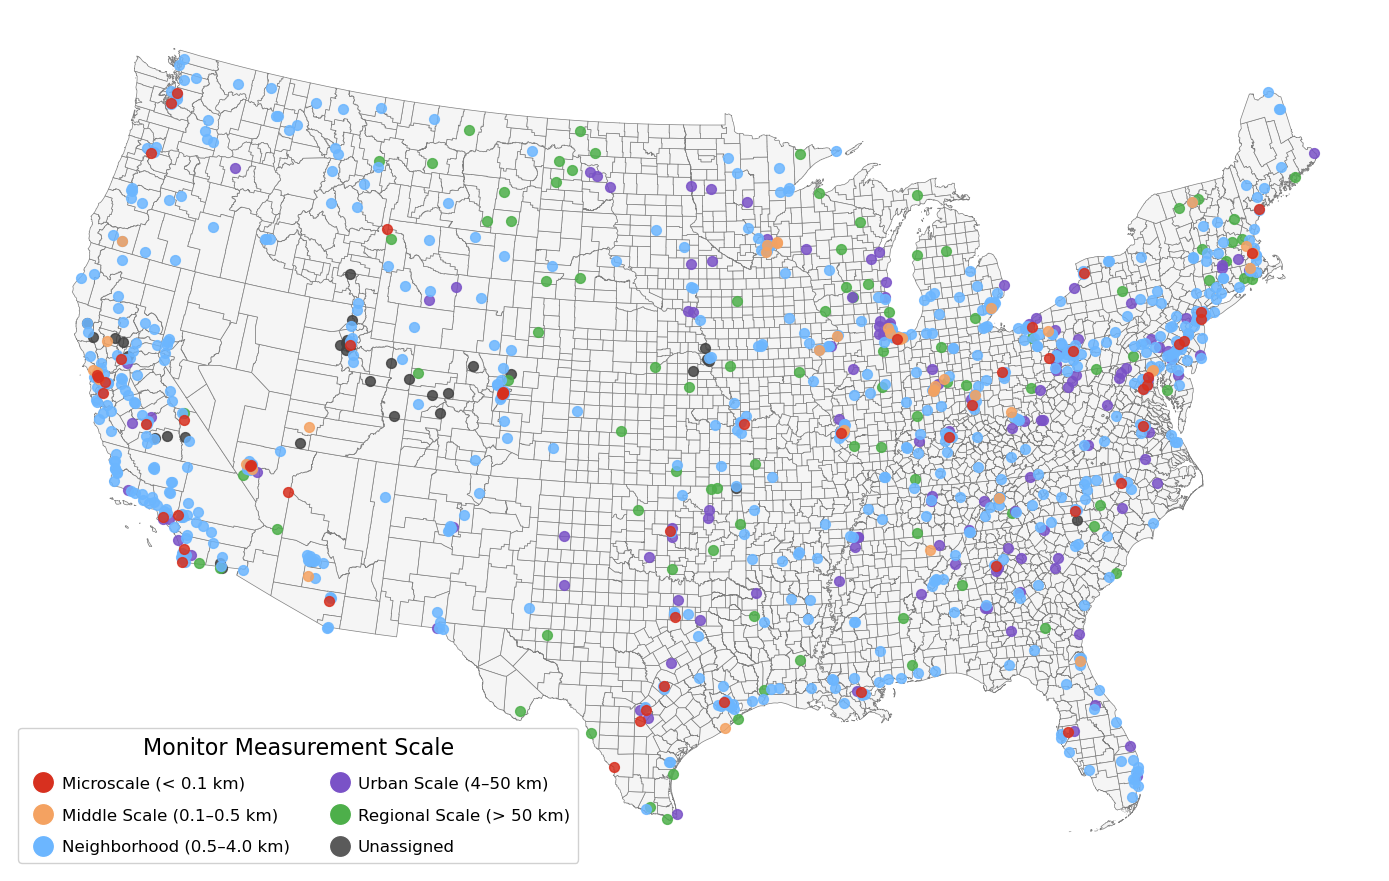

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

scale_map = {
    'REGIONAL SCALE': ('#4DAF4A', 'Regional Scale (> 50 km)'),      # softer green
    'URBAN SCALE':    ('#7A52C7', 'Urban Scale (4–50 km)'),         # medium purple
    'NEIGHBORHOOD':   ('#6CB6FF', 'Neighborhood (0.5–4.0 km)'),     # light blue
    'MIDDLE SCALE':   ('#F4A261', 'Middle Scale (0.1–0.5 km)'),     # coral/peach-orange
    'MICROSCALE':     ('#D7301F', 'Microscale (< 0.1 km)'),         # red
}

legend_colors = [
    ('#D7301F', 'Microscale (< 0.1 km)'),
    ('#F4A261', 'Middle Scale (0.1–0.5 km)'),
    ('#6CB6FF', 'Neighborhood (0.5–4.0 km)'),
    ('#7A52C7', 'Urban Scale (4–50 km)'),
    ('#4DAF4A', 'Regional Scale (> 50 km)'),
    ('#5A5A5A', 'Unassigned'),
]

fig, ax = plt.subplots(figsize=(14, 9))
counties_conus.plot(ax=ax, color='#f5f5f5', edgecolor='gray', linewidth=0.5, zorder=1)

# unassigned
unassigned = gdf_epa_clean[gdf_epa_clean['Measurement_Scale'].isna() |
                            (gdf_epa_clean['Measurement_Scale'].astype(str).str.strip() == '')]
if len(unassigned) > 0:
    ax.scatter(unassigned.geometry.x, unassigned.geometry.y,
               color='#424242', marker='o', s=50, alpha=0.85, zorder=2)

# plot largest scale first, smallest last so microscale sits on top
for z, (scale, (color, _)) in enumerate(scale_map.items(), start=3):
    subset = gdf_epa_clean[gdf_epa_clean['Measurement_Scale'] == scale]
    if len(subset) > 0:
        ax.scatter(subset.geometry.x, subset.geometry.y,
                   color=color, marker='o', s=50, alpha=0.85, zorder=z)

# counts
counts = {scale: len(gdf_epa_clean[gdf_epa_clean['Measurement_Scale'] == scale]) for scale in scale_map}
n_unassigned = len(unassigned)
for scale, count in counts.items():
    print(f"{scale}: {count}")
print(f"Unassigned: {n_unassigned}")

ax.set_axis_off()
ax.legend(
    handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                    markersize=8, label=l) for c, l in legend_colors],
    title='Monitor Measurement Scale', loc='lower left',
    fontsize=12, title_fontsize=16, framealpha=0.9, markerscale=2,
    labelspacing=1.0, handletextpad=0.1, borderpad=0.5, ncol=2)

plt.tight_layout()
plt.savefig('epa_monitors_conus.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# count unique counties
n_counties = gdf_epa_clean['GEOID'].nunique()
print(f"Total unique counties: {n_counties}")

# by scale
for scale in scale_map:
    subset = gdf_epa_clean[gdf_epa_clean['Measurement_Scale'] == scale]
    print(f"{scale}: {subset['GEOID'].nunique()} counties")

print(f"Unassigned: {unassigned['GEOID'].nunique()} counties")

Total unique counties: 630
REGIONAL SCALE: 95 counties
URBAN SCALE: 125 counties
NEIGHBORHOOD: 427 counties
MIDDLE SCALE: 33 counties
MICROSCALE: 48 counties
Unassigned: 29 counties


In [ ]:
# V5 National-scale data: 

# satdata = gpd.read_file('/data/wells/WashU_V5_GL/GLv5_GWRPM25_2021-2023_grid_cells.gpkg')

# V6 Grid data filtered to only include county bounding boxes for counties that had <= 50% 
    # CDVE - EPA Monitor Alignment from the V5 data: 
v6_cos_under50 = gpd.read_file('/data/beronio/epa_monitor/V6NA01.counties_under_50_2021-2023_grid_cells.gpkg')

NameError: name 'gpd' is not defined

In [8]:
# For V5 Data: 

# firsthalf = satdata.iloc[: len(satdata) // 2]
# secondhalf = satdata.iloc[len(satdata) // 2 :]

# For V6 Data: 

firsthalf = v6_cos_under50.iloc[: len(v6_cos_under50) // 2]
secondhalf = v6_cos_under50.iloc[len(v6_cos_under50) //2 :]

In [9]:
print('Starting transformation')
firstcrs = firsthalf.to_crs(epsg=5070)
print('second half transformation')
secondcrs = secondhalf.to_crs(epsg=5070)

satdatatrans = pd.concat([firstcrs,secondcrs], ignore_index=True)
print('transformation complete')


Starting transformation
second half transformation
transformation complete


In [10]:
satdatatrans.head()

,PM25,lat,lon,geometry
0,7.036458,25.145,-80.864998,"POLYGON ((1537499.806 356682.494, 1538506.497 ..."
1,7.153646,25.145,-80.855003,"POLYGON ((1538506.497 356844.247, 1539513.94 3..."
2,7.213542,25.145,-80.845001,"POLYGON ((1539513.94 357006.23, 1540521.365 35..."
3,7.229167,25.145,-80.834999,"POLYGON ((1540521.365 357168.319, 1541528.773 ..."
4,7.218750,25.145,-80.824997,"POLYGON ((1541528.773 357330.514, 1542535.396 ..."


In [11]:
# Remove counties with low spatial variability and apply 90th percentile

# Step 1: spatial join: assign grid cells to counties
grid_with_county = gpd.sjoin(
    # satdatatrans[['GWRPM25', 'geometry']], # 'GWRPM25 is a V5 only variable, V6 uses 'PM25'
    satdatatrans[['PM25','geometry']],
    counties_conus[['GEOID', 'geometry']],
    how='inner',
    predicate='within'
# )[['GWRPM25', 'GEOID', 'geometry']]
)[['PM25','GEOID','geometry']]

# Step 2: compute county stats (range)
county_stats = (
    # grid_with_county.groupby('GEOID')['GWRPM25']
    grid_with_county.groupby('GEOID')['PM25']
    .agg(
        county_mean='mean',
        county_std='std',
        county_min='min',
        county_max='max',
    )
    .reset_index()
)

# compute range (max - min)
county_stats['range'] = county_stats['county_max'] - county_stats['county_min']

# Step 3: exclude low-variability counties (bottom 10% of max-min range)
q10 = county_stats['range'].quantile(0.10)
print(f"Q10 range threshold: {q10:.3f}")
valid_counties = county_stats[county_stats['range'] > q10]
print(f"Counties kept: {len(valid_counties)}/{len(county_stats)} ({len(valid_counties)/len(county_stats)*100:.1f}%)")

# Step 4: keep only valid counties
grid_with_county = grid_with_county.merge(
    valid_counties[['GEOID']],
    on='GEOID',
    how='inner'
)

# Step 5: recompute stats AFTER filtering
county_stats = (
    # grid_with_county.groupby('GEOID')['GWRPM25']
    grid_with_county.groupby('GEOID')['PM25']
    .agg(
        county_mean='mean',
        county_std='std',
        # GWRPM25_90th=lambda x: x.quantile(0.90)
        PM25_90th=lambda x: x.quantile(0.90)
    )
    .reset_index()
)

grid_with_county = grid_with_county.merge(county_stats, on='GEOID')

# Step 6: select hotspots (top 10% only)
top10_sd_hotspots = grid_with_county[
    # (grid_with_county['GWRPM25'] >= grid_with_county['GWRPM25_90th']) &
    (grid_with_county['PM25'] >= grid_with_county['PM25_90th']) &

    (~grid_with_county['GEOID'].str.startswith(('02', '15')))
].copy()

Q10 range threshold: 0.258
Counties kept: 307/342 (89.8%)


In [12]:
# 1. Define scales
all_scales      = ['MICROSCALE', 'MIDDLE SCALE', 'NEIGHBORHOOD', 'URBAN SCALE', 'REGIONAL SCALE']
scale_to_buffer = {'MICROSCALE': 0.1, 'MIDDLE SCALE': 0.5, 'NEIGHBORHOOD': 4.0, 'URBAN SCALE': 50.0, 'REGIONAL SCALE': 100.0}

# 2. Buffer monitors
gdf_all = gdf_epa_clean[gdf_epa_clean['Measurement_Scale'].isin(all_scales)].copy()
gdf_all.columns


Index(['Site ID', 'Site Latitude', 'Site Longitude', 'Measurement_Scale',
       'GEOID', 'geometry'],
      dtype='object')

In [17]:
v5alignment = pd.read_csv('/data/beronio/epa_monitor/V5_misaligned_hotspots_0-50')
v5ids = list(v5alignment['GEOID'].unique())



In [18]:

distances = (gdf_all['Measurement_Scale'].map(scale_to_buffer) * 1000).to_numpy()
gdf_all['geometry_buffered'] = gdf_all.geometry.buffer(distances)
# gdf_all['geometry_buffered'] = gdf_all.geometry.buffer(gdf_all['Measurement_Scale'].map(scale_to_buffer) * 1000)

# 3. Assign monitor to county (within, fallback to nearest)
points_gdf = gpd.GeoDataFrame(
    gdf_all[['Site ID', 'Measurement_Scale']], 
    geometry=gdf_all.geometry, 
    crs=gdf_all.crs
)

monitor_county = gpd.sjoin(
    points_gdf, counties_conus[['GEOID', 'geometry']], 
    how='left', predicate='within'
)[['Site ID', 'Measurement_Scale', 'GEOID']].drop_duplicates('Site ID')

# Fallback: nearest county for unmatched monitors
unmatched = monitor_county[monitor_county['GEOID'].isna()]['Site ID']
if len(unmatched) > 0:
    nearest = gpd.sjoin_nearest(
        points_gdf[points_gdf['Site ID'].isin(unmatched)],
        counties_conus[['GEOID', 'geometry']], how='left'
    )[['Site ID', 'Measurement_Scale', 'GEOID']].drop_duplicates('Site ID')
    monitor_county = pd.concat(
        [monitor_county[monitor_county['GEOID'].notna()], nearest], # nearest county for monitor matching
        ignore_index=True
    )

# 4. Define reference sets
hotspot_geoids = set(top10_sd_hotspots['GEOID'].unique())
monitor_geoids = set(monitor_county['GEOID'].unique())
all_county_geoids = set(counties_conus['GEOID'].unique())
hotspot_with_monitor = monitor_geoids & hotspot_geoids
hotspot_without_monitor = hotspot_geoids - monitor_geoids

# 5. Flag buffer hits to ANY hotspot nearby it
hits = gpd.sjoin(
    gpd.GeoDataFrame(gdf_all[['Site ID']], geometry=gdf_all['geometry_buffered'], crs=gdf_all.crs),
    top10_sd_hotspots[['GEOID', 'geometry']], how='left', predicate='intersects'
)

# For each monitor, checking if the monitor's buffer zone spatially intersected any hotspot cell
monitor_county['zone_in_hotspot']    = monitor_county['Site ID'].isin(set(hits.dropna(subset=['GEOID'])['Site ID']))
# For each monitor, checking if the county the monitor is in contains any hotspot cells 
monitor_county['county_has_hotspot'] = monitor_county['GEOID'].isin(hotspot_geoids)

# 6. County summary of monitor-hotspot alignment (zone_in_hotspot)
county_pct = (monitor_county.groupby('GEOID')
    .agg(total_monitors=('Site ID', 'count'),
         zones_in_hotspot=('zone_in_hotspot', 'sum'))
    .reset_index())

# 7. Per-scale alignment
# Add monitor counts per scale as columns (e.g. MICROSCALE: 2, NEIGHBORHOOD: 1)
county_pct = county_pct.merge(
    monitor_county.groupby(['GEOID', 'Measurement_Scale']).size().unstack(fill_value=0).reset_index(),
    on='GEOID', how='left')

# For each measurement scale, compute % of monitors whose buffer intersected a hotspot cell
for scale in all_scales:
    sc = (monitor_county[monitor_county['Measurement_Scale'] == scale]
          .groupby('GEOID')
          .agg(
              total=('Site ID', 'count'),        # total monitors of this scale in county
              hits=('zone_in_hotspot', 'sum')    # how many had buffer overlap with hotspot
          )
          .eval('alignment = hits / total * 100'))  # % alignment for this scale
    
    # Map alignment values to county_pct
    county_pct[f'alignment_{scale}'] = county_pct['GEOID'].map(sc['alignment'])
    
    # Only report alignment for counties that actually have hotspots
    county_pct.loc[~county_pct['GEOID'].isin(hotspot_geoids), f'alignment_{scale}'] = None

# 8. Overall alignment (across all scales combined) % of monitors in hotspot counties whose buffer intersected a hotspot cell
county_pct['pct'] = (county_pct['zones_in_hotspot'] / county_pct['total_monitors'] * 100).where(county_pct['GEOID'].isin(hotspot_geoids))

# 9. Print summary
print(f"Monitors included:                          {len(gdf_all)}")
print(f"Total counties with monitors:               {len(monitor_geoids)}")
print(f"Total counties with hotspots:               {len(hotspot_geoids)}")
print(f"Monitor AND hotspot:                        {len(hotspot_with_monitor)}")
print(f"Monitor, no hotspot:                        {len(monitor_geoids - hotspot_geoids)}")
print(f"Hotspot, no monitor:                        {len(hotspot_without_monitor)} ({len(hotspot_without_monitor)/len(hotspot_geoids)*100:.1f}% of hotspot counties unmonitored)")
print(f"No monitor, no hotspot:                     {len(all_county_geoids - monitor_geoids - hotspot_geoids)}")
print(f"Overall alignment (hotspot counties only):  {county_pct[county_pct['GEOID'].isin(hotspot_geoids)]['zones_in_hotspot'].sum() / county_pct[county_pct['GEOID'].isin(hotspot_geoids)]['total_monitors'].sum() * 100:.1f}%")

Monitors included:                          982
Total counties with monitors:               614
Total counties with hotspots:               307
Monitor AND hotspot:                        179
Monitor, no hotspot:                        435
Hotspot, no monitor:                        128 (41.7% of hotspot counties unmonitored)
No monitor, no hotspot:                     2367
Overall alignment (hotspot counties only):  42.8%


In [20]:
county_pct.shape

(614, 14)

In [21]:
# Joining county geometry back in: 

counties_merged = counties_conus.merge(
    county_pct,
    on='GEOID',
    how='left'
)

# Merging in 90th percentile values 
counties_sat_merged = counties_merged.merge(
    # county_stats[['GEOID','GWRPM25_90th']],
    county_stats[['GEOID','PM25_90th']],

    on = 'GEOID',
    how = 'left'
)

# Keeping only valid alignment percentages:

alignments_merged = counties_sat_merged[counties_sat_merged['pct'].isna() == False]

# Merging monitor locations: 

monitor_locations = gdf_all.drop(columns=['Site ID', 'Site Latitude', 'Site Longitude','Measurement_Scale'])
monitor_locations = monitor_locations.rename(columns={'geometry':'monitor_geo'})

alignments_mons_merged = alignments_merged.merge(
    monitor_locations,
    on='GEOID',
    how='left'
)

merged_mons_stats = alignments_mons_merged.copy()
merged_mons_stats.head()


,STATEFP,COUNTYFP,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,geometry,total_monitors,zones_in_hotspot,...,URBAN SCALE,alignment_MICROSCALE,alignment_MIDDLE SCALE,alignment_NEIGHBORHOOD,alignment_URBAN SCALE,alignment_REGIONAL SCALE,pct,PM25_90th,monitor_geo,geometry_buffered
0,06,037,06037,Los Angeles,Los Angeles County,CA,California,"MULTIPOLYGON (((-2066923.367 1403703.122, -206...",9.0,1.0,...,1.0,0.0,NaN,0.0,100.0,NaN,11.111111,6.264844,POINT (-2017813.009 1459469.141),"POLYGON ((-2013813.009 1459469.141, -2013832.2..."
1,06,037,06037,Los Angeles,Los Angeles County,CA,California,"MULTIPOLYGON (((-2066923.367 1403703.122, -206...",9.0,1.0,...,1.0,0.0,NaN,0.0,100.0,NaN,11.111111,6.264844,POINT (-2041579.786 1480420.749),"POLYGON ((-2037579.786 1480420.749, -2037599.0..."
2,06,037,06037,Los Angeles,Los Angeles County,CA,California,"MULTIPOLYGON (((-2066923.367 1403703.122, -206...",9.0,1.0,...,1.0,0.0,NaN,0.0,100.0,NaN,11.111111,6.264844,POINT (-2020137.603 1441044.216),"POLYGON ((-2016137.603 1441044.216, -2016156.8..."
3,06,037,06037,Los Angeles,Los Angeles County,CA,California,"MULTIPOLYGON (((-2066923.367 1403703.122, -206...",9.0,1.0,...,1.0,0.0,NaN,0.0,100.0,NaN,11.111111,6.264844,POINT (-2005143.35 1449994.414),"POLYGON ((-2001143.35 1449994.414, -2001162.61..."
4,06,037,06037,Los Angeles,Los Angeles County,CA,California,"MULTIPOLYGON (((-2066923.367 1403703.122, -206...",9.0,1.0,...,1.0,0.0,NaN,0.0,100.0,NaN,11.111111,6.264844,POINT (-1993660.935 1523043.707),"POLYGON ((-1989660.935 1523043.707, -1989680.1..."


In [23]:
# Function for returning hotspot alignment ONLY data for the most misaligned counties
    # with 2+ monitors:
import os

def output_misaligned(df, range = (0,0) ):
    sorted_counties = df.sort_values(by='pct')
    rangelow = range[0]
    rangehigh = range[1]
    included = sorted_counties[(sorted_counties['pct'] >= rangelow)
                                 & (sorted_counties['pct'] <= rangehigh)]

    return rangelow, rangehigh, included


def nongrid_save(df, filepath, range = (0,0)):

    output = output_misaligned(df,range)
    data = output[2]

    filename = f'{filepath}' + f'{output[0]}-{output[1]}'
    if os.path.exists(filename):
        print('Replacing existing path in directory')
        os.remove(filename)

    print(f'Saving file to {filepath}')

    data.to_csv(filename)
    print(f'File: {filename} saved successfully.')

   

    
# Specify location for output file: 
filepathv5 = f'/data/beronio/epa_monitor/V5_misaligned_hotspots_'
filepathv6 = f'/data/beronio/epa_monitor/V6_select_counties_misaligned_hotspots_'

# nongrid_save(merged_mons_stats, filepathv6, range = (0,50))
misalignedv6ids = output_misaligned(merged_mons_stats, (0,50))[2]['GEOID'].unique()

105